<a href="https://colab.research.google.com/github/Chrisini/cosci-pygeon/blob/master/retina_cfp_od_segmentation_unlabelled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 𝕆𝕡𝕥𝕚𝕔 𝔻𝕚𝕤𝕔 𝕊𝕖𝕘𝕞𝕖𝕟𝕥𝕒𝕥𝕚𝕠𝕟

In [1]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import medmnist
    from medmnist import INFO
except:
    print("you have to install medmnist")
    !pip install medmnist
    import medmnist
    from medmnist import INFO

from torchvision import transforms


# Dataset

In [2]:
# choose dataset
data_flag = 'retinamnist'  # e.g. 'bloodmnist', 'tissuemnist', etc.

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# load datasets
dataset = DataClass(split='train', transform=transform, download=True, size=224)

print(dataset)
print(len(dataset))

# choose an image
img, label = dataset[5]

img = np.array(img)

# [-1, 1] → [0, 1]
img = (img + 1) / 2.0

# [0, 1] → [0, 255]
img = (img * 255).astype(np.uint8)

img_o = img

print("Label:", label)
print("Shape:", img.shape)

Dataset RetinaMNIST of size 224 (retinamnist_224)
    Number of datapoints: 1080
    Root location: /root/.medmnist
    Split: train
    Task: ordinal-regression
    Number of channels: 3
    Meaning of labels: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
    Number of samples: {'train': 1080, 'val': 120, 'test': 400}
    Description: The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.
    License: CC BY 4.0
1080
Label: [0]
Shape: (3, 224, 224)


# Segmentation

## Experiment 1: Segmentation by hard Recolouring

- inspired by: https://medium.com/data-science/coloring-an-image-using-crayola-colors-python-31ca1c7edb9d
- it is necessary to choose colours for each image ("palette")

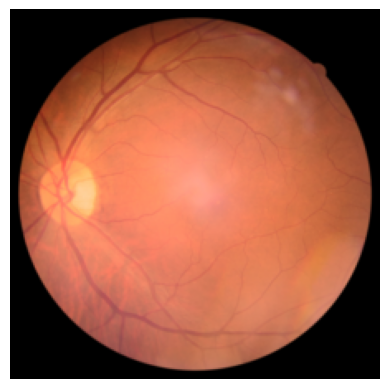

In [3]:
plt.imshow(np.transpose(img_o, (1, 2, 0))  )
plt.axis('off')
plt.show()

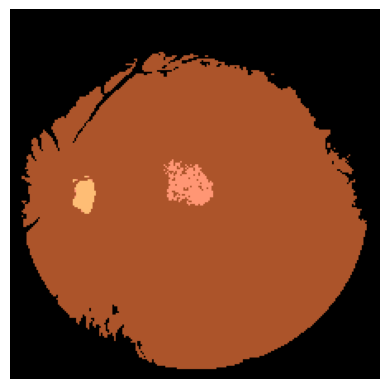

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = img_o

img = np.transpose(img, (1, 2, 0))

# Your palette of colors (list of RGB)
palette = np.array([
    [172, 84, 42],
    [255, 150, 116],     # orange
    [254, 189, 117],    # yellow
    [0,0,0],    # black
], dtype=np.uint8)

# Load image

# Flatten image array for easier processing
pixels = img.reshape(-1, 3)

# Compute distance from each pixel to each palette color
# pixels shape: (num_pixels, 3)
# palette shape: (num_colors, 3)
# We expand dims to broadcast:
distances = np.linalg.norm(pixels[:, None] - palette[None, :], axis=2)  # shape: (num_pixels, num_colors)

# Find closest palette color index for each pixel
closest_color_idx = np.argmin(distances, axis=1)

# Map pixels to closest palette colors
recolored_pixels = palette[closest_color_idx]

# Reshape back to original image shape
recolored_img = recolored_pixels.reshape(img.shape)

# Show recolored image
plt.imshow(recolored_img)
plt.axis('off')
plt.show()